# Try 2 (Revision)

In [ ]:
import pandas as pd
import numpy as np
import math
import random
from sklearn.cluster import KMeans
import time
import matplotlib.pyplot as plt

In [ ]:
sheet_id = "1z_IKjtY56_VK5hd-2YxBjuvgwJkEko5FVPm1JXIveO4"
sheet_name = "Sheet1"

csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(csv_url, decimal=',')

print(df.head())

   No                  Place                              Coordinates  \
0   1        LBB Nurul Fikri   -7.322512479985737, 112.77876084047776   
1   2  SMA Negeri 1 Surabaya   -7.257242833292316, 112.74916690952959   
2   3  SMA Negeri 2 Surabaya   -7.256427756879855, 112.74938016427122   
3   4  SMA Negeri 3 Surabaya  -7.2413221513779344, 112.79045296382363   
4   5  SMA Negeri 4 Surabaya   -7.264745426779094, 112.75501295696357   

  Start_time End_time  Service_Time  start_time_dec  end_time_dec  \
0       8:00    17:00             0             8.0         17.00   
1       6:30    15:00            25             6.5         15.00   
2       6:30    17:00            20             6.5         17.00   
3       6:30    15:15            18             6.5         15.25   
4       6:30    16:00            21             6.5         16.00   

   service_time_dec  
0              0.00  
1              0.42  
2              0.33  
3              0.30  
4              0.35  


In [ ]:
df.head()

,No,Place,Coordinates,Start_time,End_time,Service_Time,start_time_dec,end_time_dec,service_time_dec
0,1,LBB Nurul Fikri,"-7.322512479985737, 112.77876084047776",8:00,17:00,0,8.0,17.00,0.00
1,2,SMA Negeri 1 Surabaya,"-7.257242833292316, 112.74916690952959",6:30,15:00,25,6.5,15.00,0.42
2,3,SMA Negeri 2 Surabaya,"-7.256427756879855, 112.74938016427122",6:30,17:00,20,6.5,17.00,0.33
3,4,SMA Negeri 3 Surabaya,"-7.2413221513779344, 112.79045296382363",6:30,15:15,18,6.5,15.25,0.30
4,5,SMA Negeri 4 Surabaya,"-7.264745426779094, 112.75501295696357",6:30,16:00,21,6.5,16.00,0.35


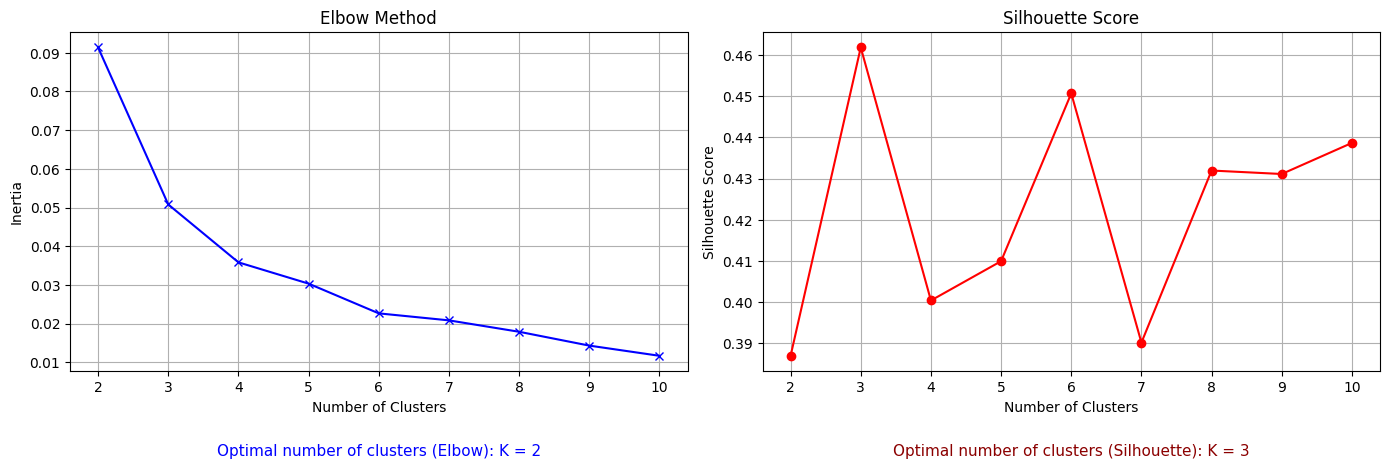


 Best Optimal Cluster : 3.


In [ ]:
from sklearn.metrics import silhouette_score

## split Coordinate into Latitude & Longitude
df[['Latitude', 'Longitude']] = ( df['Coordinates'].str.split(r',\s*', expand=True).astype(float))

# Determine clustering using the Elbow and Silhouette methods
coords = df.iloc[1:][['Latitude', 'Longitude']].copy()

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(coords)
    labels = kmeans.labels_
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(coords, labels))


# Elbow Score
inertia_diffs = np.diff(inertias)
optimal_k_elbow = K_range[np.argmax(inertia_diffs * -1)]

# Silhoutte Score
optimal_k_silhouette = K_range[silhouette_scores.index(max(silhouette_scores))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Elbow
ax1.plot(K_range, inertias, 'bx-', label='Inertia')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)
ax1.text(0.5, -0.25, f"Optimal number of clusters (Elbow): K = {optimal_k_elbow}",
         transform=ax1.transAxes, ha='center', fontsize=11, color='blue')

# Plot Silhoutte
ax2.plot(K_range, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(True)
ax2.text(0.5, -0.25, f"Optimal number of clusters (Silhouette): K = {optimal_k_silhouette}",
         transform=ax2.transAxes, ha='center', fontsize=11, color='darkred')

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

print(f"\n Best Optimal Cluster : {optimal_k_silhouette}.")

In [ ]:
# Clustering

# Mark the first row as the depot
df['is_depot'] = False
df.loc[df.index[0], 'is_depot'] = True

coords = df[['Latitude', 'Longitude']].values # coordinate from dataset

# K-Means clustering
k = optimal_k_silhouette # from optimal clustering
kmeans = KMeans(n_clusters=k, random_state=42).fit(coords)
df['cluster'] = kmeans.labels_

# Find depot index & name
depot_idx  = df.index[df['is_depot']].tolist()[0]
depot_name = df.loc[depot_idx, 'Place']

for cid in sorted(df['cluster'].unique()):
    # get member indices (exclude depot)
    member_idx = df.loc[
        (df['cluster'] == cid) & (~df['is_depot']),
        :
    ].index.tolist()

    # build route indices and names
    route_idx    = [depot_idx] + member_idx + [depot_idx]
    route_places = [depot_name] + df.loc[member_idx, 'Place'].tolist() + [depot_name]

    print("Clustering Results")
    print(f"\nRoute {cid} route indices: {route_idx}")
    print(f"Route{cid} route places : {route_places}")

Clustering Results

Route 0 route indices: [0, 11, 12, 13, 22, 33, 44, 47, 0]
Route0 route places : ['LBB Nurul Fikri', 'SMA Negeri 11 Surabaya', 'SMA Negeri 12 Surabaya', 'SMA Negeri 13 Surabaya', 'SMA Negeri 22 Surabaya', 'SMK Negeri 13 Surabaya', 'SMA Al-Azhar Surabaya', 'SMK Siang Surabaya', 'LBB Nurul Fikri']
Clustering Results

Route 1 route indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 19, 21, 24, 26, 27, 29, 30, 40, 41, 42, 45, 46, 50, 51, 52, 53, 54, 55, 56, 57, 58, 0]
Route1 route places : ['LBB Nurul Fikri', 'SMA Negeri 1 Surabaya', 'SMA Negeri 2 Surabaya', 'SMA Negeri 3 Surabaya', 'SMA Negeri 4 Surabaya', 'SMA Negeri 5 Surabaya', 'SMA Negeri 6 Surabaya', 'SMA Negeri 7 Surabaya', 'SMA Negeri 8 Surabaya', 'SMA Negeri 9 Surabaya', 'SMA Negeri 19 Surabaya', 'SMA Negeri 21 Surabaya', 'SMK Negeri 2 Surabaya', 'SMK Negeri 4 Surabaya', 'SMK Negeri 5 Surabaya', 'SMK Negeri 7 Surabaya', 'SMK Negeri 8 Surabaya', 'SMK Pariwisata Satya Widya', 'SMA Advent Anjasmoro Surabaya', 'SMA Al-Irsyad S

In [ ]:
# Identity depot
depot_idx  = df.index[df['is_depot']].tolist()[0]
depot_name = df.loc[depot_idx, 'Place']
speed_kmph = 40.0

# Haversine distance (km)
coords = df[['Latitude','Longitude']].values
def haversine(a, b, R=6371):
    lat1, lon1 = map(math.radians, a)
    lat2, lon2 = map(math.radians, b)
    dlat, dlon = lat2-lat1, lon2-lon1
    h = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 2 * R * math.atan2(math.sqrt(h), math.sqrt(1-h))

# Route Distance
def route_distance(route):
    return sum(
        haversine(coords[route[i]], coords[route[i+1]])
        for i in range(len(route)-1)
    )

# 2-Opt

def two_opt(route):
    def swap(r, i, j):
        return r[:i] + list(reversed(r[i:j])) + r[j:]
    best = route[:]
    improved = True
    while improved:
        improved = False
        for i in range(1, len(best)-2):
            for j in range(i+1, len(best)-1):
                if j == i+1:
                    continue
                cand = swap(best, i, j)
                if route_distance(cand) < route_distance(best):
                    best, improved = cand, True
        route = best
    return best


# Simulated Annealing
def simulated_annealing(route,
                        T0=3.0,
                        alpha=0.995,
                        Tmin=1e-3,
                        iter_per_T=100,
                        return_history=False):

    current = route[:]
    best = route[:]
    curr_cost = route_distance(current)
    best_cost = curr_cost

    T = T0
    history = []

    while T > Tmin:
        for _ in range(iter_per_T):
            i, j = sorted(random.sample(range(1, len(current) - 1), 2)) #2-Opt
            cand = current[:i] + list(reversed(current[i:j])) + current[j:]
            cand_cost = route_distance(cand)
            delta = cand_cost - curr_cost

            if delta < 0 or random.random() < math.exp(-delta / T):
                current, curr_cost = cand, cand_cost
                if curr_cost < best_cost:
                    best, best_cost = current[:], curr_cost

            if return_history:
                history.append(best_cost)

        T *= alpha

    if return_history:
        return best, history
    else:
        return best

# Time-window validation
def validate_time_windows(route):
    time = 0.0
    prev = route[0]
    violations = []
    for idx in route[1:]:
        travel  = haversine(coords[prev], coords[idx]) / speed_kmph
        arrival = time + travel

        # cast to float
        start = float(df.at[idx, 'start_time_dec'])
        end   = float(df.at[idx, 'end_time_dec'])

        if arrival < start:
            arrival = start
        if arrival > end:
            violations.append((df.at[idx,'Place'], arrival, (start, end)))

        time = arrival + float(df.at[idx, 'service_time_dec'])
        prev = idx

    if violations:
        print("Time-window violations:")
        for p,a,(s,e) in violations:
            print(f"   - {p}: arrival {a:.2f}h window [{s:.2f}-{e:.2f}]")
    else:
        print("No time-window violations.")

In [ ]:
def run_once(show_details=False):
    start = time.time()
    total_dist, total_time = 0.0, 0.0

    histories, distances, routes = {}, {}, {}
    combined_history = []

    for cid in sorted(df['cluster'].unique()):
        members = df.index[(df['cluster']==cid) & (~df['is_depot'])].tolist()
        if not members:
            continue

        # rute awal & 2-Opt
        route0    = [depot_idx] + members + [depot_idx]
        route_2op = two_opt(route0)
        #route_2op = two_opt(route0, max_iters=1000, max_no_improve=200)

        # Refinement SA + ambil history best_cost
        best_route, history = simulated_annealing(route_2op, return_history=True)
        histories[cid] = history
        #combined_history.extend(history)
        routes[cid]   = best_route

        # Hitung jarak
        d = route_distance(best_route)
        distances[cid] = d
        total_dist += d

        # Hitung waktu (menit)
        t_h, prev = 0.0, best_route[0]
        for idx in best_route[1:]:
            t_h += haversine(coords[prev], coords[idx]) / speed_kmph
            t_h += df.at[idx, 'service_time_dec']
            prev = idx
        total_time += t_h * 60


        if show_details:
            places = df.loc[best_route, 'Place'].tolist()
            print(f"\nRoute {cid+1}")
            print("Route: ", " → ".join(places))
            print(f"Distance:   {d:.2f} km")
            print(f"Total Time: {t_h*60:.2f} minutes")
            print("Validation:")
            validate_time_windows(best_route)

    if show_details:
        print("\n" + "="*55)
        print(f"Total Distance for All Clusters: {total_dist:.2f} km")
        print(f"Total Time for All Clusters:     {total_time:.2f} minutes")
        print("="*55 + "\n")

    H = np.vstack(list(histories.values()))  # shape = (n_cluster, M)
    total_history = H.sum(axis=0)            # shape = (M,)

    elapsed = time.time() - start
    return total_dist, total_time, histories, distances, total_history, routes

dist0, time0, hists0, dists0, hist_all0, routes0 = run_once(show_details=True)



Route 1
Route:  LBB Nurul Fikri → SMA Negeri 22 Surabaya → SMA Negeri 13 Surabaya → SMA Al-Azhar Surabaya → SMA Negeri 12 Surabaya → SMA Negeri 11 Surabaya → SMK Negeri 13 Surabaya → SMK Siang Surabaya → LBB Nurul Fikri
Distance:   44.68 km
Total Time: 196.62 minutes
Validation:
No time-window violations.

Route 2
Route:  LBB Nurul Fikri → SMA Kristen Petra 2 Surabaya → SMK Pariwisata Satya Widya → SMA Negeri 4 Surabaya → SMA Negeri 9 Surabaya → SMA Negeri 5 Surabaya → SMK Negeri 5 Surabaya → SMA Negeri 1 Surabaya → SMA Negeri 2 Surabaya → SMK Negeri 8 Surabaya → SMA Negeri 7 Surabaya → SMA PGRI 3 Surabaya → SMA HIDAYATUL UMMAH → SMA Negeri 3 Surabaya → SMA Negeri 19 Surabaya → SMA YP 17 SURABAYA → SMA Negeri 8 Surabaya → SMA Al-Irsyad Surabaya → SMA Hang Tuah - 4 Surabaya → SMA Hang Tuah 1 Surabaya → SMK Negeri 7 Surabaya → SMK Negeri 4 Surabaya → SMK Negeri 2 Surabaya → SMK Antartika Surabaya → SMA Negeri 21 Surabaya → SMA Advent Anjasmoro Surabaya → SMA Trimurti → SMA Negeri 6 Sura

In [ ]:
runs = [run_once(show_details=False) for _ in range(5)]

distances = [r[0] for r in runs]
times_min  = [r[1] for r in runs]
days       = [len(r[5]) for r in runs]

avg_dist_per_day = [d / nd for d, nd in zip(distances, days)]
avg_time_per_day = [t / nd for t, nd in zip(times_min, days)]

summary = {
    'Metric': [
        'Total distance',
        'Total time',
        'Number of routes (days)',
        'Average distance per day',
        'Average time per day'
    ],
    'Value': [
        f"{np.mean(distances):.2f} ± {np.std(distances):.2f} km",
        f"{np.mean(times_min):.2f} ± {np.std(times_min):.2f} minutes",
        f"{np.mean(days):.0f} ± {np.std(days):.0f}",
        f"{np.mean(avg_dist_per_day):.2f} ± {np.std(avg_dist_per_day):.2f} km",
        f"{np.mean(avg_time_per_day):.2f} ± {np.std(avg_time_per_day):.2f} minutes"
    ]
}

import pandas as pd
print(pd.DataFrame(summary).to_markdown(index=False))

| Metric                   | Value                  |
|:-------------------------|:-----------------------|
| Total distance           | 120.67 ± 0.09 km       |
| Total time               | 1313.80 ± 0.13 minutes |
| Number of routes (days)  | 3 ± 0                  |
| Average distance per day | 40.22 ± 0.03 km        |
| Average time per day     | 437.93 ± 0.04 minutes  |


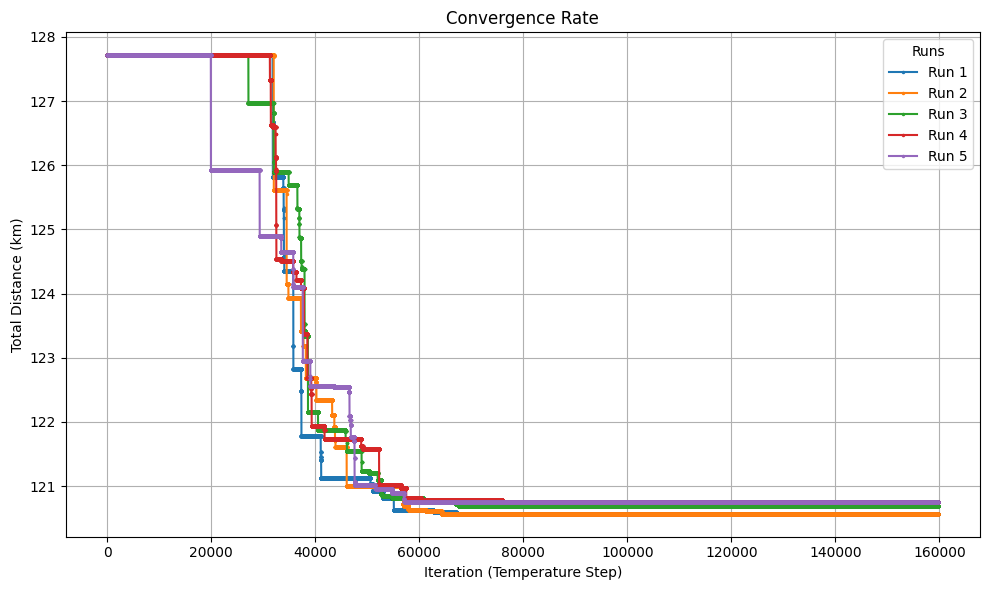

In [ ]:
# ambil history total_distance tiap run (position ke-4 di return)
runs       = [run_once(False) for _ in range(5)]
conv_hists = [r[4] for r in runs]

plt.figure(figsize=(10,6))
for i, hist in enumerate(conv_hists, start=1):
    x = np.arange(len(hist))


    plt.plot(x, hist, marker='.', markersize=3, label=f'Run {i}')

plt.title("Convergence Rate")
plt.xlabel("Iteration (Temperature Step)")
plt.ylabel("Total Distance (km)")
plt.grid(True)
plt.legend(title="Runs")
plt.tight_layout()
plt.show()

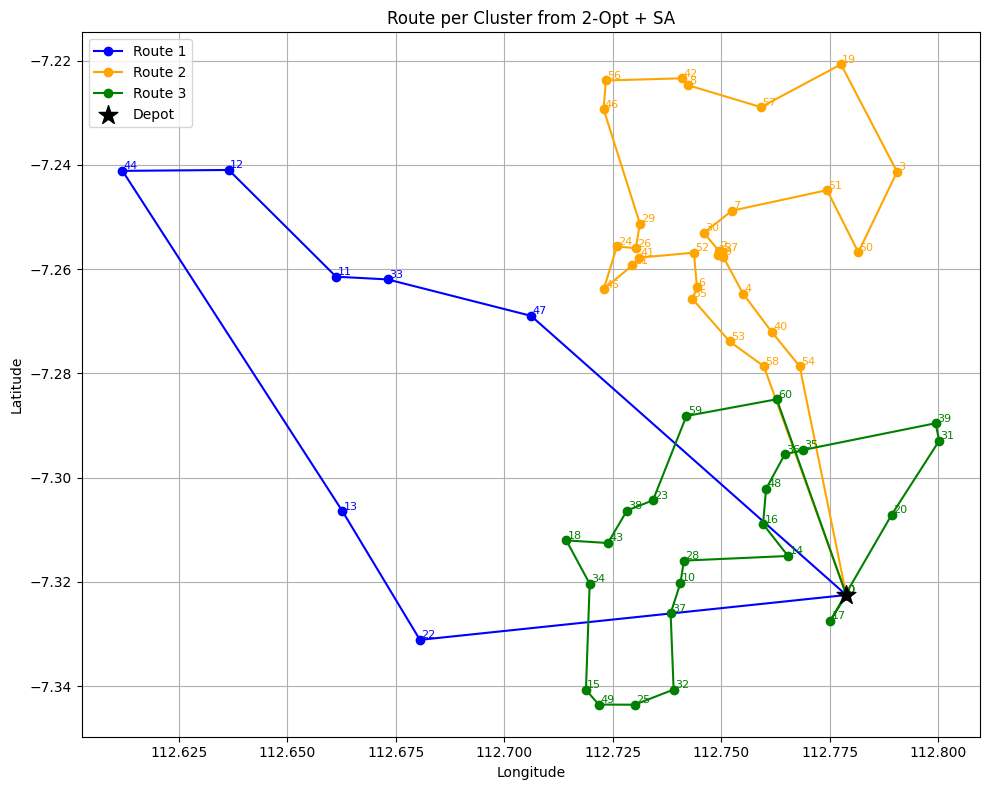

In [ ]:
colors = ['blue', 'orange', 'green', 'purple', 'cyan']
plt.figure(figsize=(10,8))

clusters = list(routes0.keys())

for cid in clusters:
    route = routes0[cid]
    lons  = df.loc[route, 'Longitude']
    lats  = df.loc[route, 'Latitude']

    # plot garis
    plt.plot(lons, lats, '-o',
             color=colors[cid % len(colors)],
             label=f'Route {cid+1}',
             markersize=6, linewidth=1.5)

    # label index
    for lon, lat, idx in zip(lons, lats, route):
        plt.text(lon+0.0003, lat+0.0003, str(idx),
                 fontsize=8, color=colors[cid % len(colors)])

# plot depot
depot_lon = df.at[depot_idx, 'Longitude']
depot_lat = df.at[depot_idx, 'Latitude']
plt.scatter([depot_lon], [depot_lat],
            marker='*', s=200, c='k', zorder=10, label='Depot')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Route per Cluster from 2-Opt + SA')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import folium
from folium.plugins import BeautifyIcon

depot_lat = df.at[depot_idx, 'Latitude']
depot_lon = df.at[depot_idx, 'Longitude']
m = folium.Map(location=[depot_lat, depot_lon], zoom_start=12)

route_colors = ['blue', 'red', 'green']
text_color = 'white'

# Plot setiap route
for cid, route in routes0.items():
    color = route_colors[cid % len(route_colors)]
    # garis rute
    coords = [(df.at[idx,'Latitude'], df.at[idx,'Longitude']) for idx in route]
    folium.PolyLine(
        coords,
        color=color,
        weight=4,
        opacity=0.8,
        tooltip=f"Route {cid+1}"
    ).add_to(m)

    # nomor marker
    for idx in route:
        lat, lon = df.at[idx,'Latitude'], df.at[idx,'Longitude']
        folium.Marker(
            location=[lat, lon],
            icon=BeautifyIcon(
                number=idx,               # tampilkan index sebagai angka
                icon_shape='marker',       # bentuk pin
                border_color='black',      # garis pinggir hitam
                border_width=2,
                text_color=text_color,     # teks hitam
                background_color=color,    # latar sesuai rute
                inner_icon_style="font-weight:bold; font-size:12px;"
            )
        ).add_to(m)

# Plot depot
folium.Marker(
    location=[depot_lat, depot_lon],
    icon=folium.Icon(color='black', icon='star'),
    popup='LBB Nurul Fikri'
).add_to(m)

m



# Try Runtime

In [ ]:
# Identity depot
depot_idx  = df.index[df['is_depot']].tolist()[0]
depot_name = df.loc[depot_idx, 'Place']
speed_kmph = 40.0

# Haversine distance (km)
coords = df[['Latitude','Longitude']].values
def haversine(a, b, R=6371):
    lat1, lon1 = map(math.radians, a)
    lat2, lon2 = map(math.radians, b)
    dlat, dlon = lat2-lat1, lon2-lon1
    h = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 2 * R * math.atan2(math.sqrt(h), math.sqrt(1-h))

# Route distance (km)
def route_distance(route):
    return sum(
        haversine(coords[route[i]], coords[route[i+1]])
        for i in range(len(route)-1)
    )

# 2-Opt local search
def two_opt(route):
    def swap(r, i, j):
        return r[:i] + list(reversed(r[i:j])) + r[j:]
    best = route[:]
    improved = True
    while improved:
        improved = False
        for i in range(1, len(best)-2):
            for j in range(i+1, len(best)-1):
                if j == i+1:
                    continue
                cand = swap(best, i, j)
                if route_distance(cand) < route_distance(best):
                    best, improved = cand, True
        # loop ulang sampai tidak ada perbaikan
    return best

def simulated_annealing(route,
                        T0=3.0,
                        alpha=0.995,
                        Tmin=1e-3,
                        iter_per_T=100,
                        return_history=False,
                        return_runtime_history=False):
    current   = route[:]
    best      = route[:]
    curr_cost = route_distance(current)
    best_cost = curr_cost

    T = T0
    cost_hist    = []
    runtime_hist = []

    start_time = time.time()
    # seed titik awal
    if return_history:
        cost_hist.append(best_cost)
    if return_runtime_history:
        runtime_hist.append(0.0)

    while T > Tmin:
        for _ in range(iter_per_T):
            i, j = sorted(random.sample(range(1, len(current)-1), 2))
            cand  = current[:i] + list(reversed(current[i:j])) + current[j:]
            cand_cost = route_distance(cand)
            delta     = cand_cost - curr_cost

            # terima solusi buruk probabilistik
            if delta < 0 or random.random() < math.exp(-delta/T):
                current, curr_cost = cand, cand_cost
                if curr_cost < best_cost:
                    best, best_cost = current[:], curr_cost

            if return_history:      cost_hist.append(best_cost)
            if return_runtime_history: runtime_hist.append(time.time() - start_time)

        T *= alpha

    # return sesuai flag
    if return_history and return_runtime_history:
        return best, cost_hist, runtime_hist
    if return_history:
        return best, cost_hist
    if return_runtime_history:
        return best, runtime_hist
    return best


# Time‐window validation
def validate_time_windows(route):
    t        = 0.0
    prev     = route[0]
    violations = []
    for idx in route[1:]:
        travel  = haversine(coords[prev], coords[idx]) / speed_kmph
        arrival = t + travel
        start   = float(df.at[idx, 'start_time_dec'])
        end     = float(df.at[idx, 'end_time_dec'])
        if arrival < start:
            arrival = start
        if arrival > end:
            violations.append((df.at[idx,'Place'], arrival, (start, end)))
        t = arrival + float(df.at[idx, 'service_time_dec'])
        prev = idx
    if violations:
        print("Time‐window violations:")
        for p,a,(s,e) in violations:
            print(f"  - {p}: arrival {a:.2f}h window [{s:.2f}-{e:.2f}]")
    else:
        print("No time‐window violations.")


In [ ]:
def run_once(show_details=False):
    start = time.time()
    total_dist, total_time = 0.0, 0.0

    histories, distances, routes = {}, {}, {}
    combined_history = []

    for cid in sorted(df['cluster'].unique()):
        members = df.index[(df['cluster']==cid)&(~df['is_depot'])].tolist()
        if not members:
            continue

        # rute awal + 2‐Opt
        route0   = [depot_idx] + members + [depot_idx]
        route_2o = two_opt(route0)

        # Refinement SA + ambil cost‐history
        best_route, cost_hist, rt_hist = simulated_annealing(
            route_2o,
            return_history=True,
            return_runtime_history=True
        )
        histories[cid] = cost_hist
        routes[cid]    = best_route

        # Hitung jarak & waktu
        d = route_distance(best_route)
        distances[cid] = d
        total_dist += d

        # waktu (menit)
        t_h, prev = 0.0, best_route[0]
        for idx in best_route[1:]:
            t_h += haversine(coords[prev], coords[idx]) / speed_kmph
            t_h += df.at[idx, 'service_time_dec']
            prev = idx
        total_time += t_h*60

        if show_details:
            places = df.loc[best_route, 'Place'].tolist()
            print(f"\nRoute {cid+1}")
            print("Route:  ", " → ".join(places))
            print(f"Distance:   {d:.2f} km")
            print(f"Total Time: {t_h*60:.2f} minutes")
            print("Validation:")
            validate_time_windows(best_route)

    if show_details:
        print("\n" + "="*55)
        print(f"Total Distance All Clusters: {total_dist:.2f} km")
        print(f"Total Time     All Clusters: {total_time:.2f} minutes")
        print("="*55 + "\n")


    hist_arrays = [np.array(h) for h in histories.values() if len(h) > 0]

    if hist_arrays:
      # cari panjang terpanjang
      max_len = max(arr.size for arr in hist_arrays)
      padded = []
      for arr in hist_arrays:
          pad_width = max_len - arr.size
          if pad_width > 0:
            # pad dengan mengulang elemen terakhir
              arr = np.concatenate([arr, np.full(pad_width, arr[-1])])
          padded.append(arr)
      H = np.vstack(padded)
      total_history = H.sum(axis=0)
    else:
      total_history = np.array([])

    elapsed = time.time() - start
    return total_dist, total_time, histories, distances, total_history, routes


dist0, time0, hists0, dists0, hist_all0, routes0 = run_once(show_details=True)


Route 1
Route:   LBB Nurul Fikri → SMA Negeri 22 Surabaya → SMA Negeri 13 Surabaya → SMA Al-Azhar Surabaya → SMA Negeri 12 Surabaya → SMA Negeri 11 Surabaya → SMK Negeri 13 Surabaya → SMK Siang Surabaya → LBB Nurul Fikri
Distance:   44.68 km
Total Time: 196.62 minutes
Validation:
No time‐window violations.

Route 2
Route:   LBB Nurul Fikri → SMA Kristen Petra 2 Surabaya → SMK Pariwisata Satya Widya → SMA HIDAYATUL UMMAH → SMA PGRI 3 Surabaya → SMA Negeri 3 Surabaya → SMA Negeri 19 Surabaya → SMA YP 17 SURABAYA → SMA Negeri 8 Surabaya → SMA Al-Irsyad Surabaya → SMA Hang Tuah - 4 Surabaya → SMA Hang Tuah 1 Surabaya → SMK Negeri 7 Surabaya → SMK Negeri 4 Surabaya → SMK Negeri 2 Surabaya → SMK Antartika Surabaya → SMA Negeri 21 Surabaya → SMA Advent Anjasmoro Surabaya → SMA Dapena 1 Surabaya → SMA Negeri 6 Surabaya → SMA Trimurti → SMK Negeri 8 Surabaya → SMA Negeri 7 Surabaya → SMA Negeri 2 Surabaya → SMA Negeri 1 Surabaya → SMK Negeri 5 Surabaya → SMA Negeri 5 Surabaya → SMA Negeri 9 Su

In [ ]:
runs = [run_once(show_details=False) for _ in range(5)]

distances = [r[0] for r in runs]
times_min  = [r[1] for r in runs]
days       = [len(r[5]) for r in runs]

avg_dist_per_day = [d / nd for d, nd in zip(distances, days)]
avg_time_per_day = [t / nd for t, nd in zip(times_min, days)]

summary = {
    'Metric': [
        'Total distance',
        'Total time',
        'Number of routes (days)',
        'Average distance per day',
        'Average time per day'
    ],
    'Value': [
        f"{np.mean(distances):.2f} ± {np.std(distances):.2f} km",
        f"{np.mean(times_min):.2f} ± {np.std(times_min):.2f} minutes",
        f"{np.mean(days):.0f} ± {np.std(days):.0f}",
        f"{np.mean(avg_dist_per_day):.2f} ± {np.std(avg_dist_per_day):.2f} km",
        f"{np.mean(avg_time_per_day):.2f} ± {np.std(avg_time_per_day):.2f} minutes"
    ]
}

import pandas as pd
print(pd.DataFrame(summary).to_markdown(index=False))

| Metric                   | Value                  |
|:-------------------------|:-----------------------|
| Total distance           | 120.68 ± 0.07 km       |
| Total time               | 1313.82 ± 0.11 minutes |
| Number of routes (days)  | 3 ± 0                  |
| Average distance per day | 40.23 ± 0.02 km        |
| Average time per day     | 437.94 ± 0.04 minutes  |


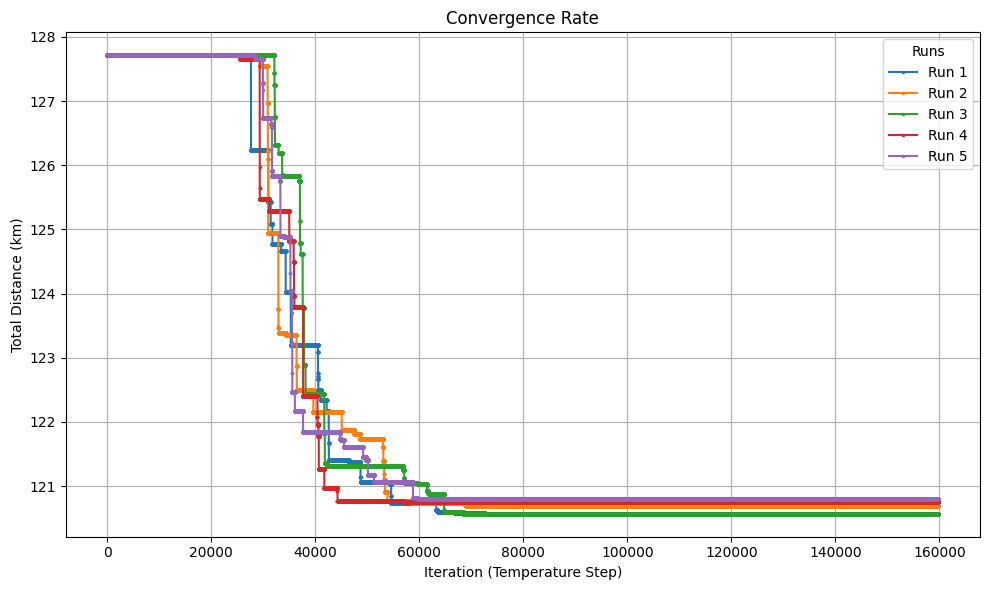

In [ ]:
# ambil history total_distance tiap run (position ke-4 di return)
runs       = [run_once(False) for _ in range(5)]
conv_hists = [r[4] for r in runs]

plt.figure(figsize=(10,6))
for i, hist in enumerate(conv_hists, start=1):

    x = np.arange(len(hist))
    plt.plot(x, hist, marker='.', markersize=3, label=f'Run {i}')

plt.title("Convergence Rate")
plt.xlabel("Iteration (Temperature Step)")
plt.ylabel("Total Distance (km)")
plt.grid(True)
plt.legend(title="Runs")
plt.tight_layout()
plt.show()

In [ ]:
def plot_convergence(*convergences, labels=None):
    plt.figure(figsize=(10,6))
    colors = ['blue', 'green', 'orange']
    if labels is None:
        labels = [f'Algoritma {i+1}' for i in range(len(convergences))]

    for i, conv in enumerate(convergences):
        plt.plot(conv, label=labels[i], color=colors[i % len(colors)])

    plt.xlabel('Iteration')
    plt.ylabel('Best Distance (km)')
    plt.title('Convergence Graph')
    plt.legend()
    plt.grid(True)
    plt.show()

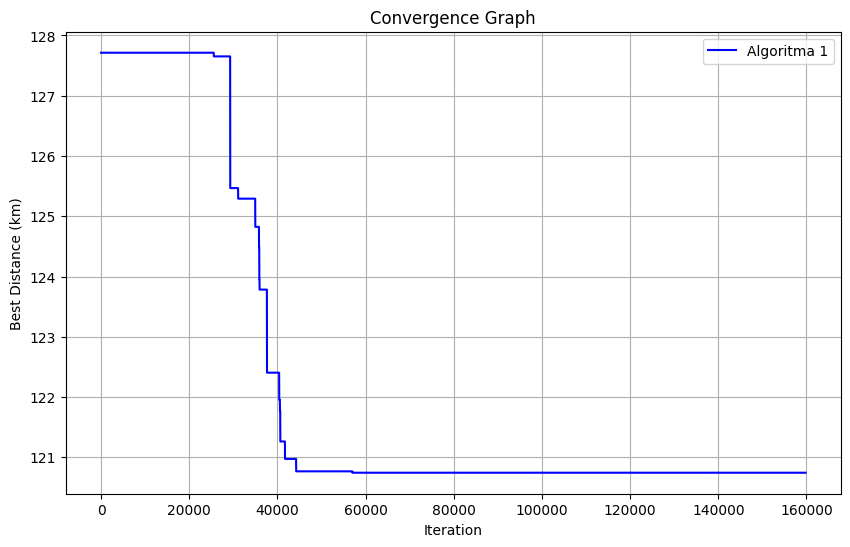

In [ ]:
# Cari index run dengan total distance terkecil
best_run_idx = np.argmin(distances)

# Ambil history convergence dari run tersebut
best_run_history = conv_hists[best_run_idx]

convergence_sa_2opt = best_run_history
plot_convergence( convergence_sa_2opt)


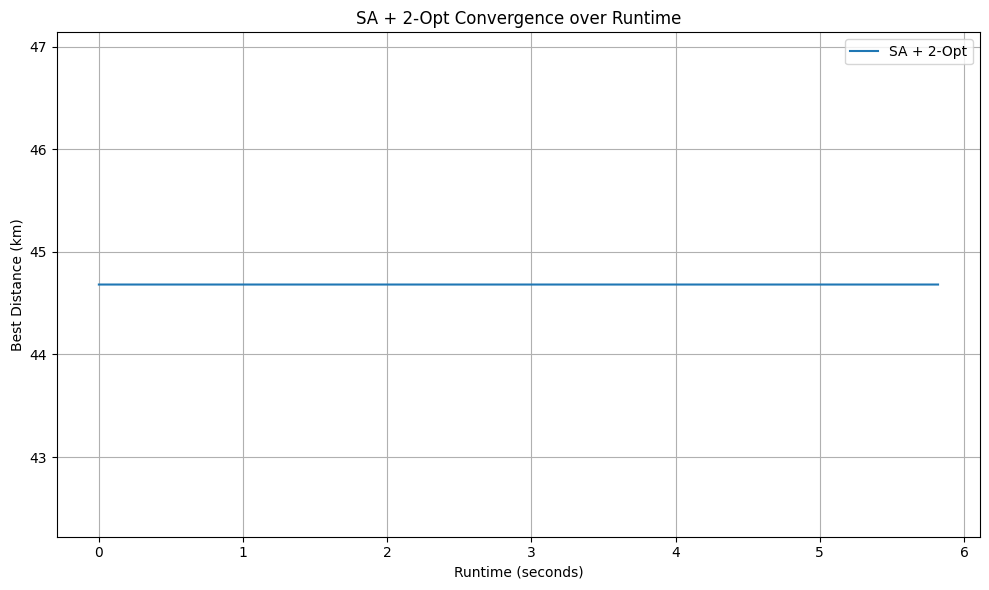

In [ ]:
members = df.index[(df['cluster']==0)&(~df['is_depot'])].tolist()
route0 = [depot_idx] + members + [depot_idx]
route_2op = two_opt(route0)

best, cost_hist, rt_hist = simulated_annealing(
    route_2op,
    return_history=True,
    return_runtime_history=True
)

plt.figure(figsize=(10,6))
plt.plot(rt_hist, cost_hist, marker='None', label='SA + 2-Opt')
plt.xlabel("Runtime (seconds)")
plt.ylabel("Best Distance (km)")
plt.title("SA + 2-Opt Convergence over Runtime")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

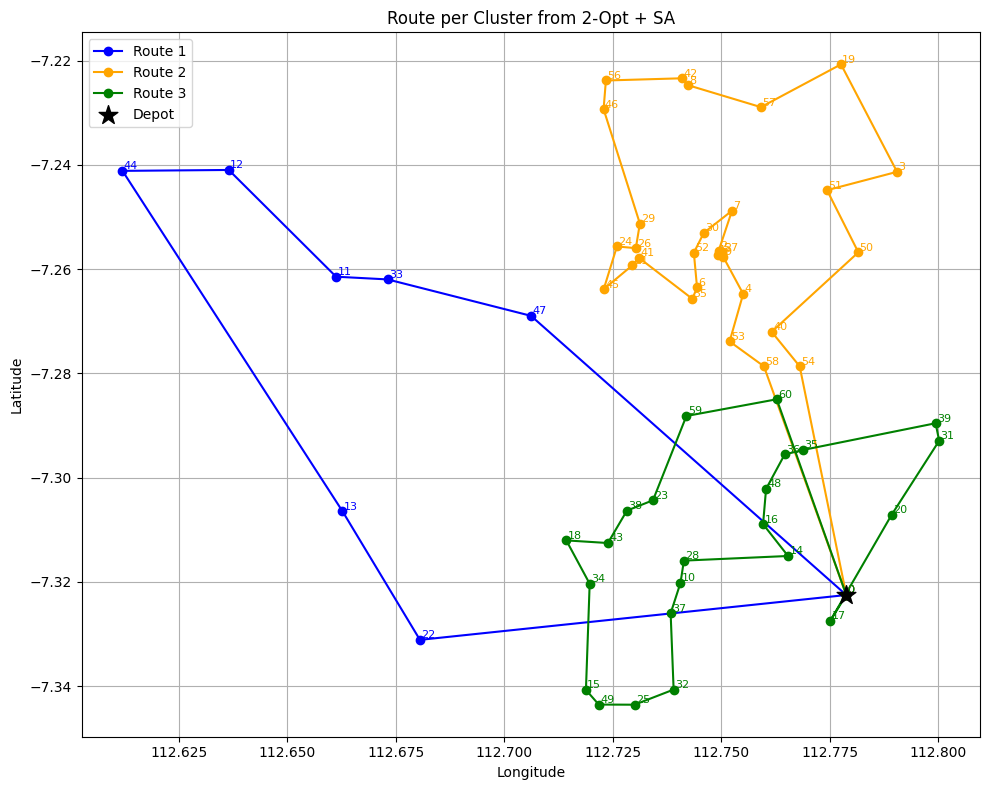

In [ ]:
colors = ['blue', 'orange', 'green', 'purple', 'cyan']
plt.figure(figsize=(10,8))

clusters = list(routes0.keys())

for cid in clusters:
    route = routes0[cid]
    lons  = df.loc[route, 'Longitude']
    lats  = df.loc[route, 'Latitude']

    # plot garis
    plt.plot(lons, lats, '-o',
             color=colors[cid % len(colors)],
             label=f'Route {cid+1}',
             markersize=6, linewidth=1.5)

    # label index
    for lon, lat, idx in zip(lons, lats, route):
        plt.text(lon+0.0003, lat+0.0003, str(idx),
                 fontsize=8, color=colors[cid % len(colors)])

# plot depot
depot_lon = df.at[depot_idx, 'Longitude']
depot_lat = df.at[depot_idx, 'Latitude']
plt.scatter([depot_lon], [depot_lat],
            marker='*', s=200, c='k', zorder=10, label='Depot')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Route per Cluster from 2-Opt + SA')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import folium
from folium.plugins import BeautifyIcon

depot_lat = df.at[depot_idx, 'Latitude']
depot_lon = df.at[depot_idx, 'Longitude']
m = folium.Map(location=[depot_lat, depot_lon], zoom_start=12)

route_colors = ['blue', 'red', 'green']
text_color = 'white'

# Plot setiap route
for cid, route in routes0.items():
    color = route_colors[cid % len(route_colors)]
    # garis rute
    coords = [(df.at[idx,'Latitude'], df.at[idx,'Longitude']) for idx in route]
    folium.PolyLine(
        coords,
        color=color,
        weight=4,
        opacity=0.8,
        tooltip=f"Route {cid+1}"
    ).add_to(m)

    # nomor marker
    for idx in route:
        lat, lon = df.at[idx,'Latitude'], df.at[idx,'Longitude']
        folium.Marker(
            location=[lat, lon],
            icon=BeautifyIcon(
                number=idx,               # tampilkan index sebagai angka
                icon_shape='marker',       # bentuk pin
                border_color='black',      # garis pinggir hitam
                border_width=2,
                text_color=text_color,     # teks hitam
                background_color=color,    # latar sesuai rute
                inner_icon_style="font-weight:bold; font-size:12px;"
            )
        ).add_to(m)

# Plot depot
folium.Marker(
    location=[depot_lat, depot_lon],
    icon=folium.Icon(color='black', icon='star'),
    popup='LBB Nurul Fikri'
).add_to(m)

m



# Try Runtime